In [1456]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [1457]:
df = pd.read_csv('heart.csv')
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


# EDA and Data clening

In [1458]:
df.shape

(918, 12)

In [1459]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [1460]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [1461]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [1462]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

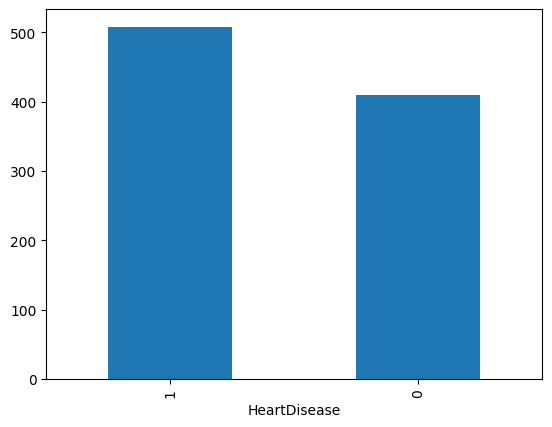

In [1463]:
df['HeartDisease'].value_counts().plot(kind = 'bar')

In [1464]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [1465]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

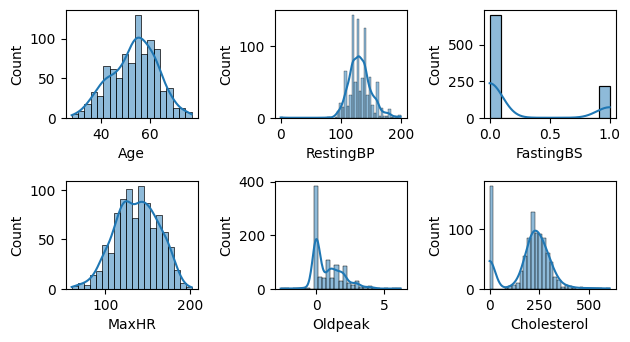

In [1466]:
def ploting (var , num):
    plt.subplot(3 ,3 , num)
    sns.histplot(df[var] , kde = True)

ploting('Age' , 1)
ploting('RestingBP' , 2)
ploting('FastingBS' , 3)
ploting('MaxHR' , 4)
ploting('Oldpeak' , 5)
ploting('Cholesterol' , 6)


plt.tight_layout()


In [1467]:
resting_bp_mean = df.loc[df['RestingBP'] != 0 , 'RestingBP'].mean()
resting_bp_mean

np.float64(132.54089422028352)

In [1468]:
df['RestingBP'] = df['RestingBP'].replace(0 , resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

In [1469]:
cholesterol_mean = df.loc[df['Cholesterol'] != 0 , 'Cholesterol'].mean()

In [1470]:
df['Cholesterol'] = df['Cholesterol'].replace(0 , cholesterol_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

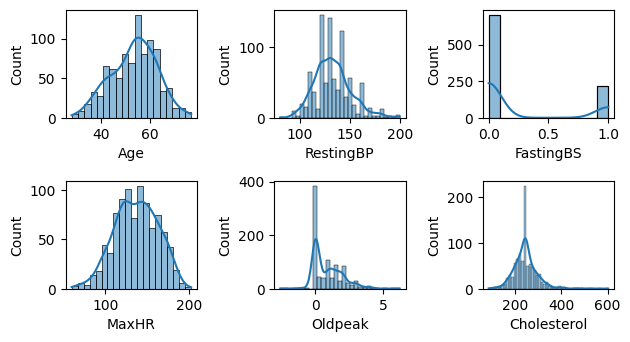

In [1471]:
ploting('Age' , 1)
ploting('RestingBP' , 2)
ploting('FastingBS' , 3)
ploting('MaxHR' , 4)
ploting('Oldpeak' , 5)
ploting('Cholesterol' , 6)


plt.tight_layout()

In [1472]:
pd.DataFrame(df)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


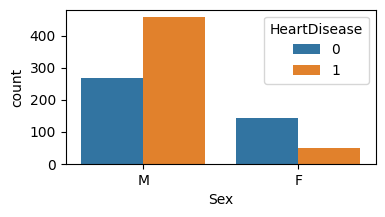

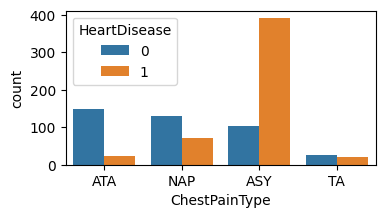

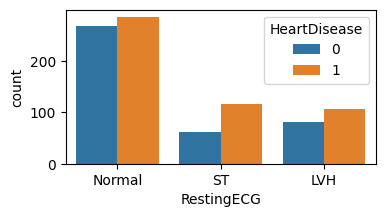

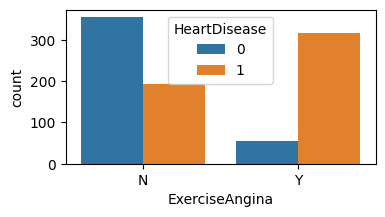

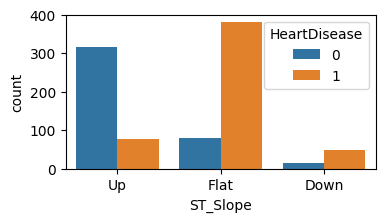

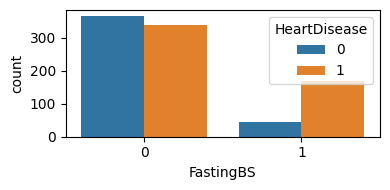

In [1473]:
def bar(val, num , hue):
    plt.figure(figsize = (4 , 2))
    sns.countplot(x = df[val] , hue = df[hue])
    
bar('Sex' , 1 , 'HeartDisease')
bar('ChestPainType' , 2 , 'HeartDisease')
bar('RestingECG' , 3 , 'HeartDisease')
bar('ExerciseAngina' , 4 , 'HeartDisease')
bar('ST_Slope' , 5 , 'HeartDisease')
bar('FastingBS' , 6 , 'HeartDisease')
plt.tight_layout()


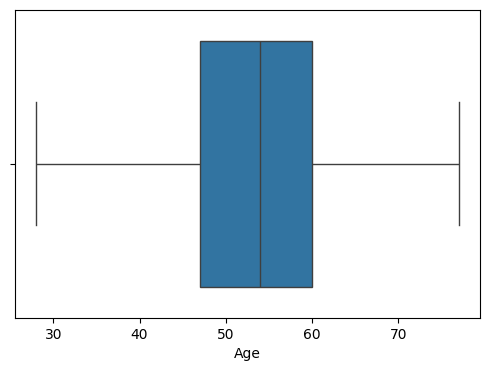

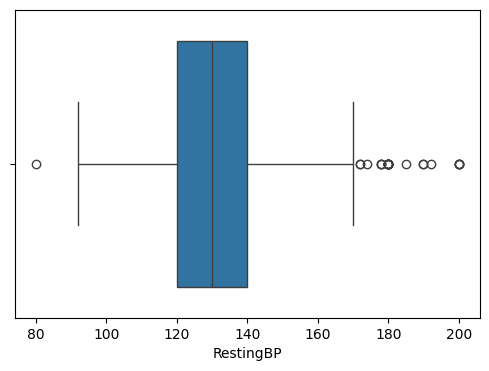

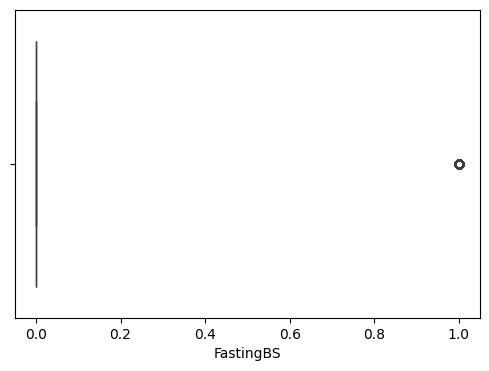

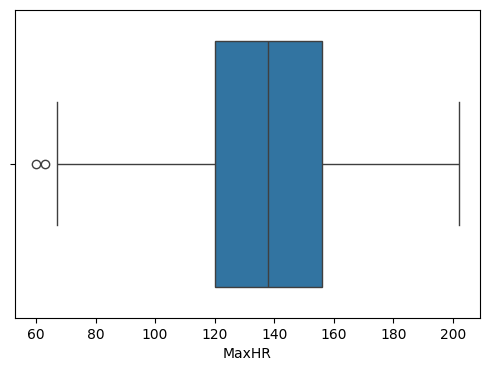

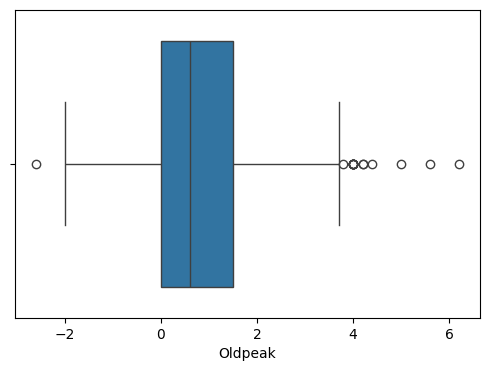

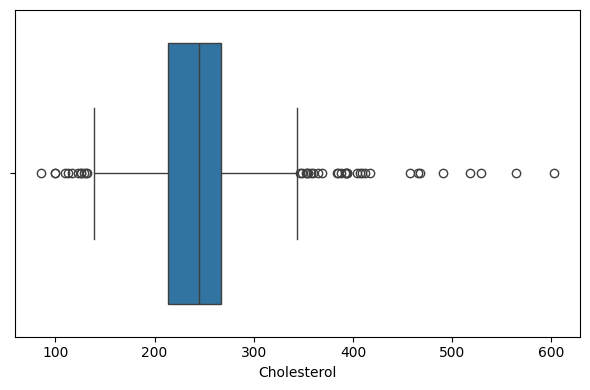

In [1474]:
def box_ploting (var , num):
    plt.figure(figsize = (6,4))
    sns.boxplot(x = df[var])

box_ploting('Age' , 1)
box_ploting('RestingBP' , 2)
box_ploting('FastingBS' , 3)
box_ploting('MaxHR' , 4)
box_ploting('Oldpeak' , 5)
box_ploting('Cholesterol' , 6)


plt.tight_layout()

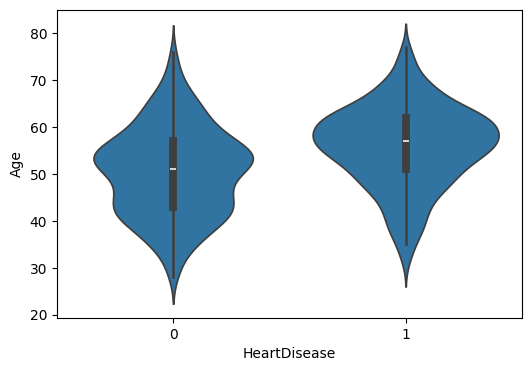

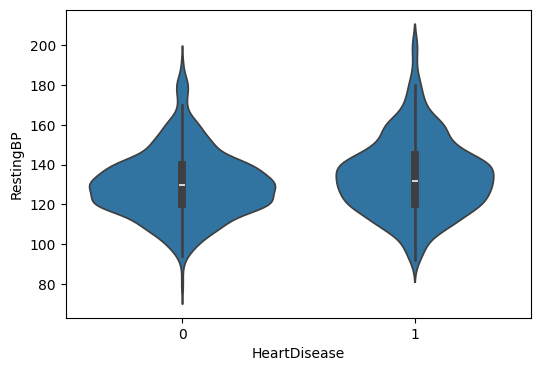

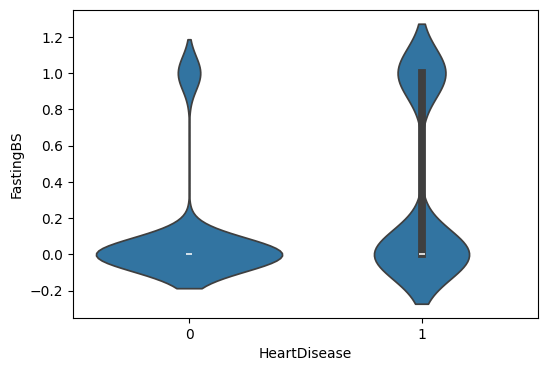

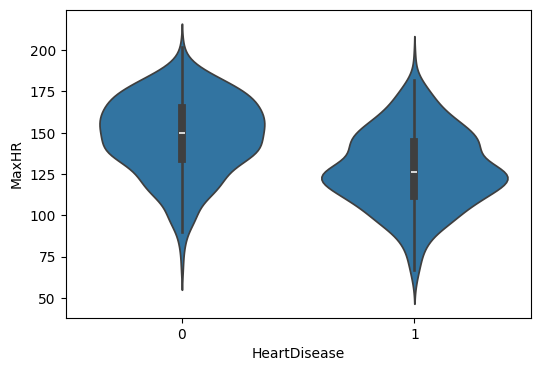

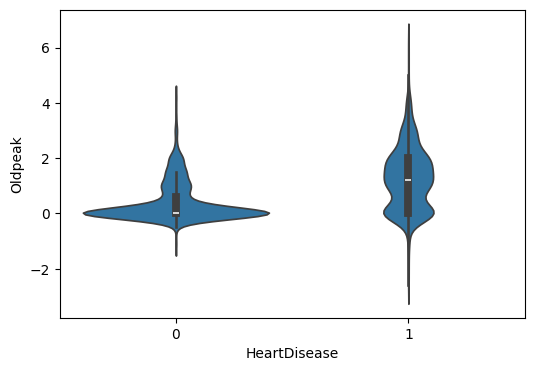

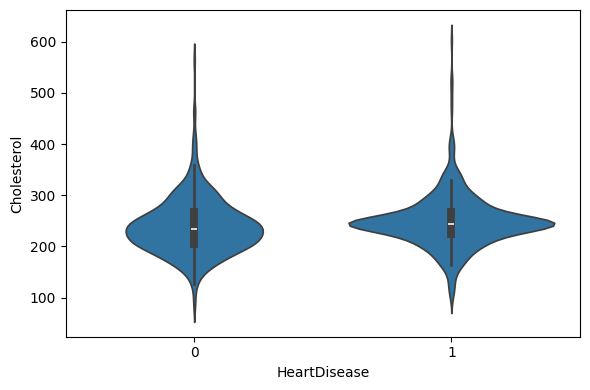

In [1475]:
def violin_ploting (var , he):
    plt.figure(figsize = (6,4))
    sns.violinplot( y = df[he] ,x = df[var] , data = df)

violin_ploting('HeartDisease','Age')
violin_ploting('HeartDisease','RestingBP')
violin_ploting('HeartDisease','FastingBS')
violin_ploting('HeartDisease','MaxHR')
violin_ploting('HeartDisease','Oldpeak')
violin_ploting('HeartDisease','Cholesterol')


plt.tight_layout()

<Axes: >

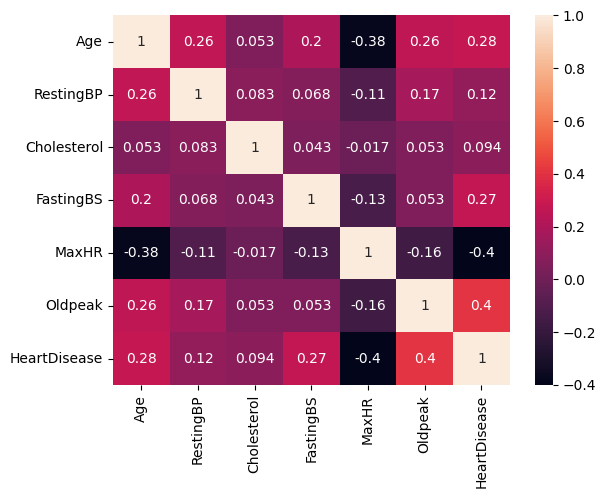

In [1476]:
sns.heatmap(df.corr(numeric_only = True) , annot = True)

# Data preprocessing

In [1477]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [1478]:
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

# Level encoding

In [1479]:
df['Sex'] = df['Sex'].map({'M':0 , 'F':1})

In [1480]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,0,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,0,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,1,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [1481]:
df['ExerciseAngina'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [1482]:
df['ExerciseAngina'] = df['ExerciseAngina'].map({
    'N':0,
    'Y':1
})

In [1483]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140.0,289.0,0,Normal,172,0,0.0,Up,0
1,49,1,NAP,160.0,180.0,0,Normal,156,0,1.0,Flat,1
2,37,0,ATA,130.0,283.0,0,ST,98,0,0.0,Up,0
3,48,1,ASY,138.0,214.0,0,Normal,108,1,1.5,Flat,1
4,54,0,NAP,150.0,195.0,0,Normal,122,0,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,TA,110.0,264.0,0,Normal,132,0,1.2,Flat,1
914,68,0,ASY,144.0,193.0,1,Normal,141,0,3.4,Flat,1
915,57,0,ASY,130.0,131.0,0,Normal,115,1,1.2,Flat,1
916,57,1,ATA,130.0,236.0,0,LVH,174,0,0.0,Flat,1


# One hot Encoding 

In [1484]:
encoded_df = pd.get_dummies(df , drop_first = True)

In [1485]:
encoded_df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140.0,289.0,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,1,160.0,180.0,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,0,130.0,283.0,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,1,138.0,214.0,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,0,150.0,195.0,0,122,0,0.0,0,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110.0,264.0,0,132,0,1.2,1,False,False,True,True,False,True,False
914,68,0,144.0,193.0,1,141,0,3.4,1,False,False,False,True,False,True,False
915,57,0,130.0,131.0,0,115,1,1.2,1,False,False,False,True,False,True,False
916,57,1,130.0,236.0,0,174,0,0.0,1,True,False,False,False,False,True,False


In [1486]:
encoded_df = encoded_df.astype(int)
encoded_df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1
5,39,0,120,339,0,170,0,0,0,0,1,0,1,0,0,1
6,45,1,130,237,0,170,0,0,0,1,0,0,1,0,0,1
7,54,0,110,208,0,142,0,0,0,1,0,0,1,0,0,1
8,37,0,140,207,0,130,1,1,1,0,0,0,1,0,1,0
9,48,1,120,284,0,120,0,0,0,1,0,0,1,0,0,1


In [1487]:
encoded_df.shape

(918, 16)

In [1488]:
encoded_df.duplicated().sum()

np.int64(0)

In [1489]:
encoded_df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1,1,0,0,1,1,0,1,0
914,68,0,144,193,1,141,0,3,1,0,0,0,1,0,1,0
915,57,0,130,131,0,115,1,1,1,0,0,0,1,0,1,0
916,57,1,130,236,0,174,0,0,1,1,0,0,0,0,1,0


In [1490]:
from sklearn.preprocessing import StandardScaler
numerical_columns = ['Age','RestingBP', 'Cholesterol','MaxHR',
       'Oldpeak',]
scaler = StandardScaler()
encoded_df[numerical_columns] = scaler.fit_transform(df[numerical_columns])


In [1491]:
encoded_df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0,0.414853,0.832513,0,1.382928,0,-0.832432,0,1,0,0,1,0,0,1
1,-0.478484,1,1.527192,-1.212938,0,0.754157,0,0.105664,1,0,1,0,1,0,1,0
2,-1.751359,0,-0.141317,0.719919,0,-1.525138,0,-0.832432,0,1,0,0,0,1,0,1
3,-0.584556,1,0.303619,-0.574908,0,-1.132156,1,0.574711,1,0,0,0,1,0,1,0
4,0.051881,0,0.971022,-0.931454,0,-0.581981,0,-0.832432,0,0,1,0,1,0,0,1
5,-1.539213,0,-0.697486,1.770793,0,1.304332,0,-0.832432,0,0,1,0,1,0,0,1
6,-0.902775,1,-0.141317,-0.143299,0,1.304332,0,-0.832432,0,1,0,0,1,0,0,1
7,0.051881,0,-1.253656,-0.687501,0,0.203982,0,-0.832432,0,1,0,0,1,0,0,1
8,-1.751359,0,0.414853,-0.706267,0,-0.267596,1,0.574711,1,0,0,0,1,0,1,0
9,-0.584556,1,-0.697486,0.738685,0,-0.660578,0,-0.832432,0,1,0,0,1,0,0,1


In [1492]:
encoded_df.columns

Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [1493]:
from scipy.stats import pearsonr

selected_feature = ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']

correlation = {
    feature: pearsonr(encoded_df[feature] , encoded_df['HeartDisease']) [0]
    for feature in selected_feature
}
correlation_df = pd.DataFrame(list(correlation.items()), columns = ['Feature' , 'Pearsonr Correlation'])
correlation_df.sort_values(by = 'Pearsonr Correlation', ascending = False)

,Feature,Pearsonr Correlation
13,ST_Slope_Flat,0.554134
6,ExerciseAngina,0.494282
7,Oldpeak,0.403951
0,Age,0.282039
4,FastingBS,0.267291
2,RestingBP,0.117938
12,RestingECG_ST,0.102527
3,Cholesterol,0.094082
10,ChestPainType_TA,-0.054790
11,RestingECG_Normal,-0.091580


<Axes: >

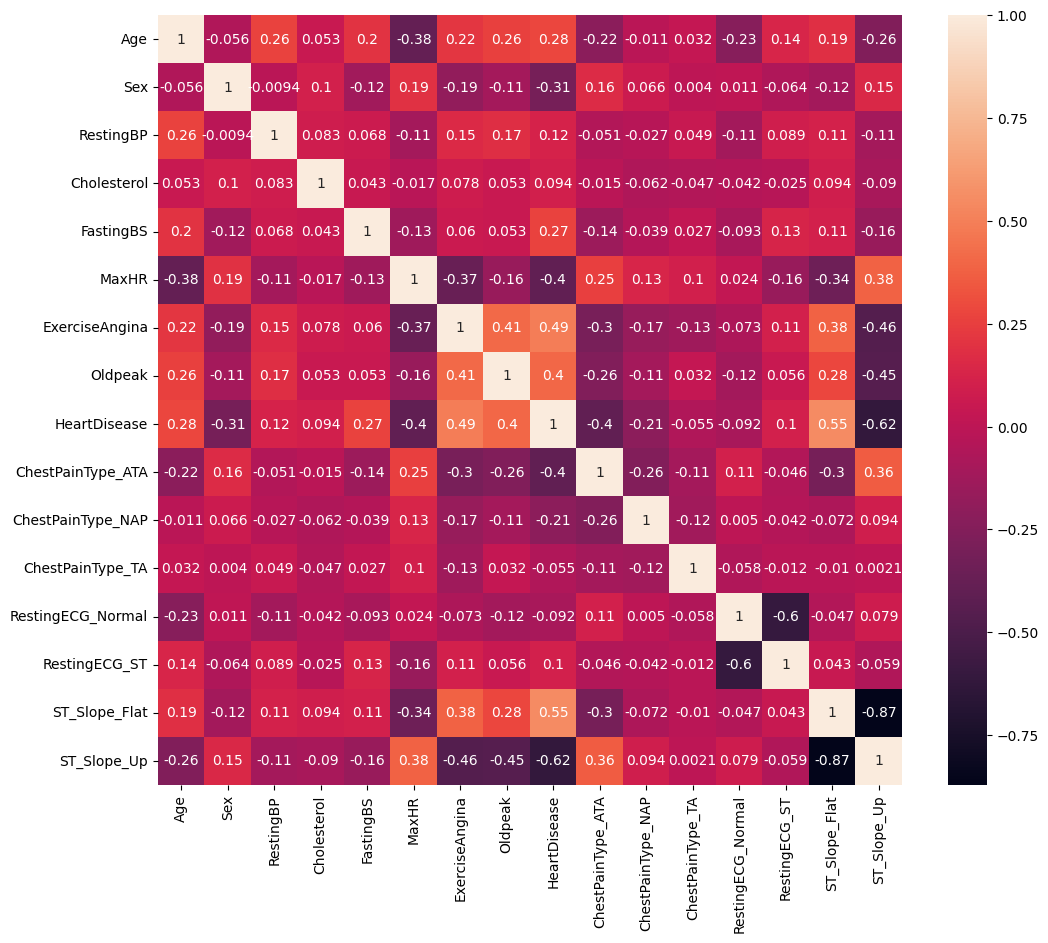

In [1494]:
plt.figure(figsize = (12 , 10))
sns.heatmap(encoded_df.corr(numeric_only = True) , annot=True)

In [1495]:
encoded_df.columns

Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [1496]:
encoded_df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0,0.414853,0.832513,0,1.382928,0,-0.832432,0,1,0,0,1,0,0,1
1,-0.478484,1,1.527192,-1.212938,0,0.754157,0,0.105664,1,0,1,0,1,0,1,0
2,-1.751359,0,-0.141317,0.719919,0,-1.525138,0,-0.832432,0,1,0,0,0,1,0,1
3,-0.584556,1,0.303619,-0.574908,0,-1.132156,1,0.574711,1,0,0,0,1,0,1,0
4,0.051881,0,0.971022,-0.931454,0,-0.581981,0,-0.832432,0,0,1,0,1,0,0,1
5,-1.539213,0,-0.697486,1.770793,0,1.304332,0,-0.832432,0,0,1,0,1,0,0,1
6,-0.902775,1,-0.141317,-0.143299,0,1.304332,0,-0.832432,0,1,0,0,1,0,0,1
7,0.051881,0,-1.253656,-0.687501,0,0.203982,0,-0.832432,0,1,0,0,1,0,0,1
8,-1.751359,0,0.414853,-0.706267,0,-0.267596,1,0.574711,1,0,0,0,1,0,1,0
9,-0.584556,1,-0.697486,0.738685,0,-0.660578,0,-0.832432,0,1,0,0,1,0,0,1


In [1497]:
final_columns = ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease','ChestPainType_ATA',
       'ChestPainType_NAP','RestingECG_Normal','ChestPainType_TA',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']
encoded_df = encoded_df[final_columns]
encoded_df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,ChestPainType_TA,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0,0.414853,0.832513,0,1.382928,0,-0.832432,0,1,0,1,0,0,0,1
1,-0.478484,1,1.527192,-1.212938,0,0.754157,0,0.105664,1,0,1,1,0,0,1,0
2,-1.751359,0,-0.141317,0.719919,0,-1.525138,0,-0.832432,0,1,0,0,0,1,0,1
3,-0.584556,1,0.303619,-0.574908,0,-1.132156,1,0.574711,1,0,0,1,0,0,1,0
4,0.051881,0,0.971022,-0.931454,0,-0.581981,0,-0.832432,0,0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,0,-1.253656,0.363372,0,-0.188999,0,0.293283,1,0,0,1,1,0,1,0
914,1.536902,0,0.637321,-0.968986,1,0.164684,0,2.357094,1,0,0,1,0,0,1,0
915,0.370100,0,-0.141317,-2.132453,0,-0.857069,1,0.293283,1,0,0,1,0,0,1,0
916,0.370100,1,-0.141317,-0.162065,0,1.461525,0,-0.832432,1,1,0,0,0,0,1,0


In [1498]:
encoded_df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,ChestPainType_TA,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0,0.414853,0.832513,0,1.382928,0,-0.832432,0,1,0,1,0,0,0,1
1,-0.478484,1,1.527192,-1.212938,0,0.754157,0,0.105664,1,0,1,1,0,0,1,0
2,-1.751359,0,-0.141317,0.719919,0,-1.525138,0,-0.832432,0,1,0,0,0,1,0,1
3,-0.584556,1,0.303619,-0.574908,0,-1.132156,1,0.574711,1,0,0,1,0,0,1,0
4,0.051881,0,0.971022,-0.931454,0,-0.581981,0,-0.832432,0,0,1,1,0,0,0,1
5,-1.539213,0,-0.697486,1.770793,0,1.304332,0,-0.832432,0,0,1,1,0,0,0,1
6,-0.902775,1,-0.141317,-0.143299,0,1.304332,0,-0.832432,0,1,0,1,0,0,0,1
7,0.051881,0,-1.253656,-0.687501,0,0.203982,0,-0.832432,0,1,0,1,0,0,0,1
8,-1.751359,0,0.414853,-0.706267,0,-0.267596,1,0.574711,1,0,0,1,0,0,1,0
9,-0.584556,1,-0.697486,0.738685,0,-0.660578,0,-0.832432,0,1,0,1,0,0,0,1


In [1499]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , f1_score , classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score

In [1500]:
X = encoded_df.drop('HeartDisease' , axis = 1)
y = encoded_df['HeartDisease']

In [1501]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [1502]:
models = {
    'LogisticRegression':LogisticRegression(),
    'GaussianNB':GaussianNB(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'SVC':SVC(kernel='rbf'),
    'DecisionTreeClassifier':DecisionTreeClassifier()
}

In [1503]:
result = []

In [1504]:
for name,model in models.items():
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        'model':name,
        'accuracy':round(acc , 4),
        'f1 score':round(f1 , 4),
    })

In [1505]:
result

[{'model': 'LogisticRegression', 'accuracy': 0.8641, 'f1 score': 0.8792},
 {'model': 'GaussianNB', 'accuracy': 0.8478, 'f1 score': 0.8614},
 {'model': 'KNeighborsClassifier', 'accuracy': 0.8587, 'f1 score': 0.8785},
 {'model': 'SVC', 'accuracy': 0.837, 'f1 score': 0.8585},
 {'model': 'DecisionTreeClassifier', 'accuracy': 0.788, 'f1 score': 0.8098}]

In [1506]:
linear = LinearRegression()

In [1507]:
linear_model = linear.fit(X_train , y_train)
linear_y_pred = linear_model.predict(X_test)

In [1508]:
r2 = r2_score(y_test,linear_y_pred)
r2

0.5339105013616645

In [1509]:
n = X.shape[0]
p = X.shape[1]

In [1510]:
adjusted_r2 = 1 - ((1 - r2) * ( n - 1) / ( n - p - 1))
adjusted_r2

0.526159567348832